# Step 4 — Historical Analysis: Outage x Weather

**Objective:** Merge outage + weather panels, compute outage rates by compound event category, run county-FE panel regressions, linear probability models with FE, and regression discontinuity.

**Specifications:**
- Panel OLS: `log1p(total_customer_hours) = α_county + γ_month + β·CategoryDummies + ε` with SEs clustered at county.
  Day FE intentionally omitted — it absorbs the spatial weather signal because heatwaves hit all counties simultaneously.
- Linear Probability Model with county FE for the binary `outage_event_flag`. Conditional logit reported as a robustness check on a subset.
- Regressors are mutually exclusive weather categories (`normal | heatwave_only | heat_wind | heat_precip | triple`) to avoid the multicollinearity of nested compound flags.
- RD: ERCOT 36°C (Conservation Appeal) and CAISO 38°C (Flex Alert). The CAISO RD measures program effectiveness — a negative τ above the cutoff indicates the alert reduces outages.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config.settings import PROCESSED, RD_THRESHOLD_ERCOT_C, RD_THRESHOLD_CAISO_C
from src.analysis.compound_flags import outage_rates_by_category, add_weather_flags
from src.analysis.panel_regression import run_panel_ols, run_logit, summarise_results
from src.analysis.rd_analysis import run_rd, rd_bandwidth_sensitivity
from src.viz.maps import outage_rate_bar, outage_heatmap, rd_plot


## 4.1 Load processed panels

In [2]:
def load_panel(path):
    if path.exists():
        df = pd.read_csv(path, parse_dates=['date'])
        df['fips'] = df['fips'].astype(str).str.zfill(5)
        return df.set_index(['fips', 'date'])
    print(f'Not found: {path}')
    return None

outage_ercot  = load_panel(PROCESSED['outage_ercot'])
weather_ercot = load_panel(PROCESSED['weather_ercot'])
outage_caiso  = load_panel(PROCESSED['outage_caiso'])
weather_caiso = load_panel(PROCESSED['weather_caiso'])
print('ERCOT outage:', outage_ercot.shape  if outage_ercot  is not None else 'missing')
print('ERCOT weather:', weather_ercot.shape if weather_ercot is not None else 'missing')


ERCOT outage: (497425, 6)
ERCOT weather: (335042, 12)


## 4.2 Merge panels

In [3]:
merged_ercot = merged_caiso = None
if outage_ercot is not None and weather_ercot is not None:
    merged_ercot = outage_ercot.join(weather_ercot, how='inner')
    if 'weather_category' not in merged_ercot.columns:
        merged_ercot = add_weather_flags(merged_ercot)
    print(f'Merged ERCOT panel: {merged_ercot.shape}')
if outage_caiso is not None and weather_caiso is not None:
    merged_caiso = outage_caiso.join(weather_caiso, how='inner')
    if 'weather_category' not in merged_caiso.columns:
        merged_caiso = add_weather_flags(merged_caiso)
    print(f'Merged CAISO panel: {merged_caiso.shape}')


Merged ERCOT panel: (284388, 18)
Merged CAISO panel: (111195, 18)


## 4.3 Outage rates by weather category

Replicates the key finding from the Nature 2025 EAGLE-I study: compound triple events (heat + wind + precip) amplify outage probability by ~52x.

ERCOT outage rates by category:
                          category  n_days  n_outage_days  outage_rate  relative_risk
              Normal (no heatwave)  198576          21200     0.106760       1.000000
                     Heatwave only   85229           8576     0.100623       0.942515
             Compound: heat + wind     394            131     0.332487       3.114340
Compound triple (heat+wind+precip)     189            120     0.634921       5.947170


/burg-archive/home/mck2199/electric-grid-resilience/src/viz/maps.py:318: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(rates_df["category"], rotation=20, ha="right")


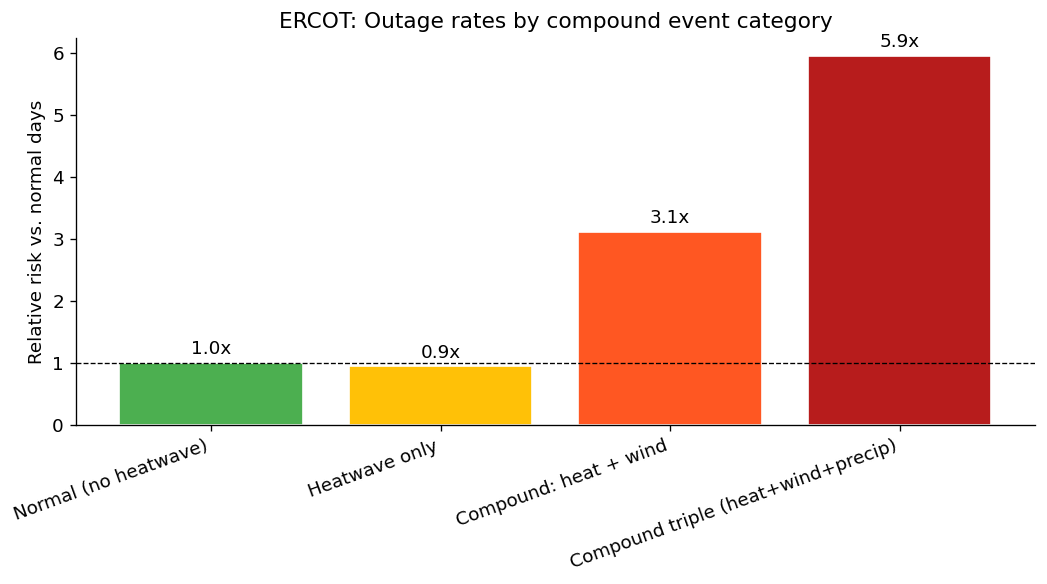

In [4]:
if merged_ercot is not None:
    rates = outage_rates_by_category(merged_ercot.reset_index())
    print('ERCOT outage rates by category:')
    print(rates.to_string(index=False))

    fig, ax = plt.subplots(figsize=(9, 5))
    outage_rate_bar(rates, ax=ax, title='ERCOT: Outage rates by compound event category')
    plt.tight_layout()
    plt.savefig('../data/processed/ercot_outage_rates.png', dpi=150)
    plt.show()


## 4.4 Outage severity heatmap (county x time)

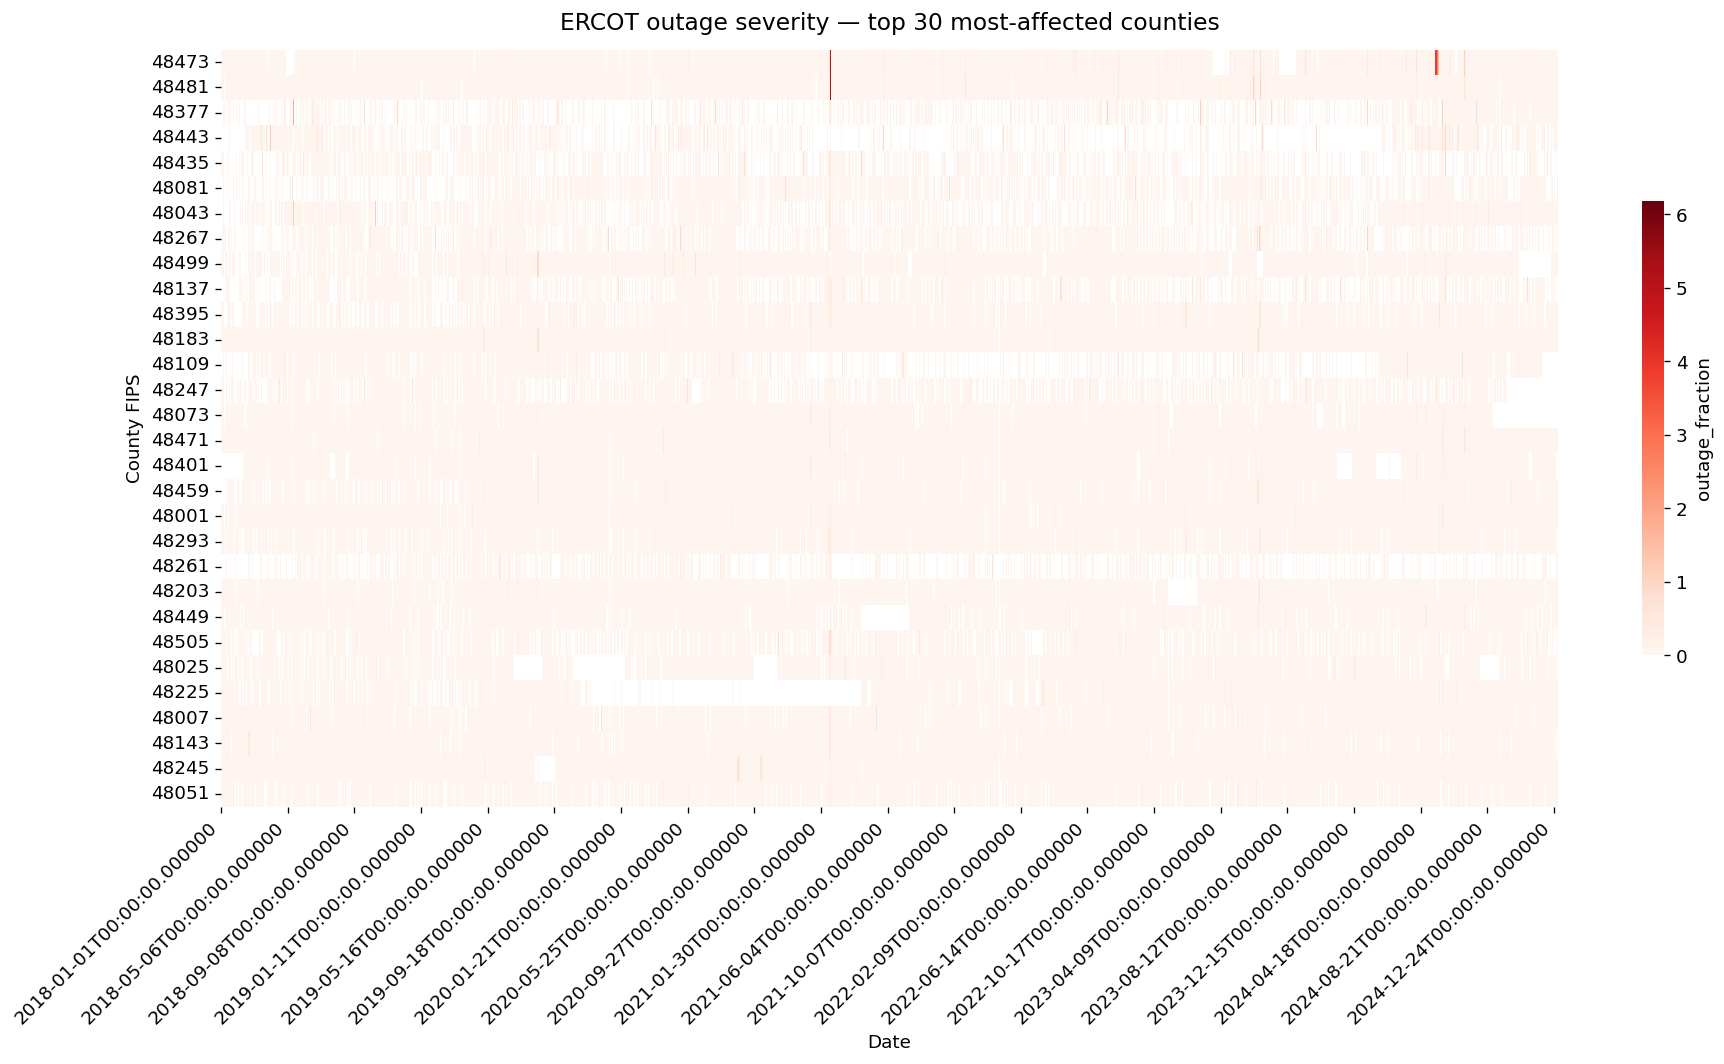

In [5]:
if merged_ercot is not None:
    fig, ax = plt.subplots(figsize=(16, 9))
    outage_heatmap(
        merged_ercot.reset_index(),
        value_col='outage_fraction',
        top_n_counties=30,
        title='ERCOT outage severity — top 30 most-affected counties',
        ax=ax,
    )
    plt.tight_layout()
    plt.savefig('../data/processed/ercot_outage_heatmap.png', dpi=150)
    plt.show()


## 4.5 Fixed-effects panel OLS

In [6]:
if merged_ercot is not None:
    print('=== ERCOT Panel OLS — county FE + month FE, log1p(total_customer_hours) ===')
    result_ols = run_panel_ols(
        merged_ercot,
        outcome='total_customer_hours',
        use_categories=True,
        log_outcome=True,
        entity_effects=True,
        time_effects=False,
        add_month_fe=True,
    )
    print(result_ols.summary)
    print('\nCoefficient table (weather categories vs. baseline=normal):')
    coefs = summarise_results(result_ols)
    cat_coefs = coefs[coefs.index.str.startswith('cat_')]
    print(cat_coefs.round(4))


=== ERCOT Panel OLS — county FE + month FE, log1p(total_customer_hours) ===


                              PanelOLS Estimation Summary                               
Dep. Variable:     log1p_total_customer_hours   R-squared:                        0.0361
Estimator:                           PanelOLS   R-squared (Between):              0.1451
No. Observations:                      284388   R-squared (Within):               0.0361
Date:                        Sun, May 10 2026   R-squared (Overall):              0.1254
Time:                                14:23:42   Log-likelihood                -5.619e+05
Cov. Estimator:                     Clustered                                           
                                                F-statistic:                      709.96
Entities:                                 133   P-value                           0.0000
Avg Obs:                               2138.3   Distribution:               F(15,284240)
Min Obs:                               409.00                                           
Max Obs:             

## 4.6 Logistic regression for binary outage events

In [7]:
if merged_ercot is not None:
    print('=== ERCOT Linear Probability Model — county FE, outage_event_flag ===')
    result_lpm = run_logit(
        merged_ercot,
        outcome='outage_event_flag',
        use_categories=True,
        method='lpm',
    )
    print(result_lpm.summary)
    print('\nLPM coefficients (probability points vs. baseline=normal):')
    coefs = summarise_results(result_lpm)
    cat_coefs = coefs[coefs.index.str.startswith('cat_')]
    print(cat_coefs.round(4))


=== ERCOT Linear Probability Model — county FE, outage_event_flag ===


                          PanelOLS Estimation Summary                           
Dep. Variable:      outage_event_flag   R-squared:                        0.0074
Estimator:                   PanelOLS   R-squared (Between):             -0.0017
No. Observations:              284388   R-squared (Within):               0.0074
Date:                Sun, May 10 2026   R-squared (Overall):              0.0059
Time:                        14:23:44   Log-likelihood                -6.239e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      527.30
Entities:                         133   P-value                           0.0000
Avg Obs:                       2138.3   Distribution:                F(4,284251)
Min Obs:                       409.00                                           
Max Obs:                       2508.0   F-statistic (robust):             114.48
                            

## 4.7 Regression Discontinuity — ERCOT Conservation Appeal threshold (36°C)

Note: ERCOT RD has shown bandwidth instability in prior runs (sign flips at wider bandwidths). The bandwidth sensitivity table below reports estimates across multiple bandwidths so the reader can judge robustness — do not cherry-pick a significant bandwidth.


RD Estimate (outcome=total_customer_hours, running=tmax)
  Cutoff:    36.0 °C
  Bandwidth: 0.50 °C
  N (left):  5649
  N (right): 7069
  τ:         334.4194  (SE=381.2537)
  t-stat:    0.877
  p-value:   0.3804
  95% CI:    [-412.8953, 1081.7341]




Bandwidth sensitivity:
   bandwidth          tau          se   p_value     ci_lower     ci_upper  \
0        1.0   572.614848  244.647181  0.019262    93.093005  1052.136690   
1        1.5   632.721851  315.570267  0.044970    14.193807  1251.249896   
2        2.0  1462.177247  652.813838  0.025108   182.652614  2741.701880   
3        2.5  1132.822023  700.459406  0.105829  -240.082513  2505.726559   
4        3.0   564.417669  651.181148  0.386077  -711.896540  1840.731878   
5        4.0  -559.482418  558.921043  0.316827 -1654.962688   535.997852   
6        5.0  -898.824138  504.641053  0.074896 -1887.913929    90.265653   

   n_left  n_right  
0   13396    12776  
1   17658    16866  
2   25740    21164  
3   32425    24241  
4   40999    27326  
5   56163    31328  
6   70613    33466  


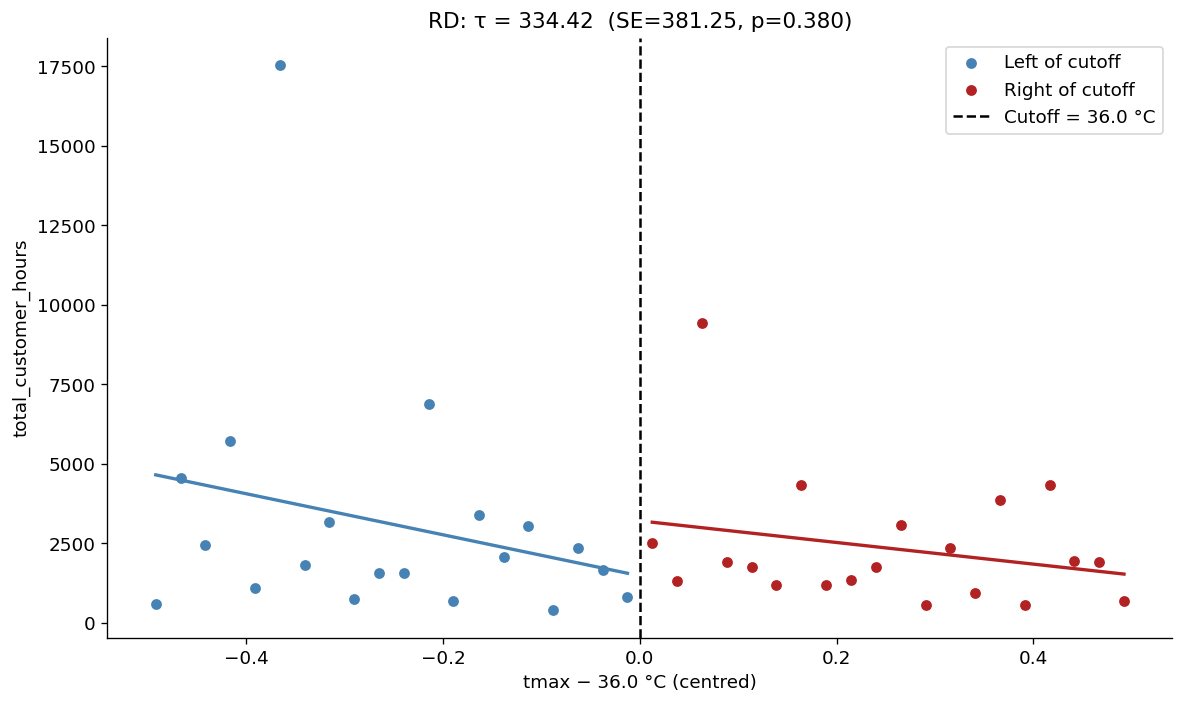

In [8]:
if merged_ercot is not None:
    rd_result = run_rd(
        merged_ercot.reset_index(),
        cutoff=RD_THRESHOLD_ERCOT_C,
        running_var='tmax',
        outcome='total_customer_hours',
    )
    print(rd_result.summary())

    bw_sens = rd_bandwidth_sensitivity(merged_ercot.reset_index(), cutoff=RD_THRESHOLD_ERCOT_C)
    print('\nBandwidth sensitivity:')
    print(bw_sens)

    fig, ax = plt.subplots(figsize=(10, 6))
    rd_plot(merged_ercot.reset_index(), rd_result, ax=ax)
    plt.tight_layout()
    plt.savefig('../data/processed/ercot_rd_plot.png', dpi=150)
    plt.show()


## 4.3b–4.7b CAISO analysis
Repeat key analyses for CAISO (38 °C Flex Alert RD cutoff).


CAISO outage rates by category:
                          category  n_days  n_outage_days  outage_rate  relative_risk
              Normal (no heatwave)   94055          11573     0.123045       1.000000
                     Heatwave only   17130           2248     0.131232       1.066534
             Compound: heat + wind       9              2     0.222222       1.806024
Compound triple (heat+wind+precip)       1              0     0.000000       0.000000


/burg-archive/home/mck2199/electric-grid-resilience/src/viz/maps.py:318: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(rates_df["category"], rotation=20, ha="right")


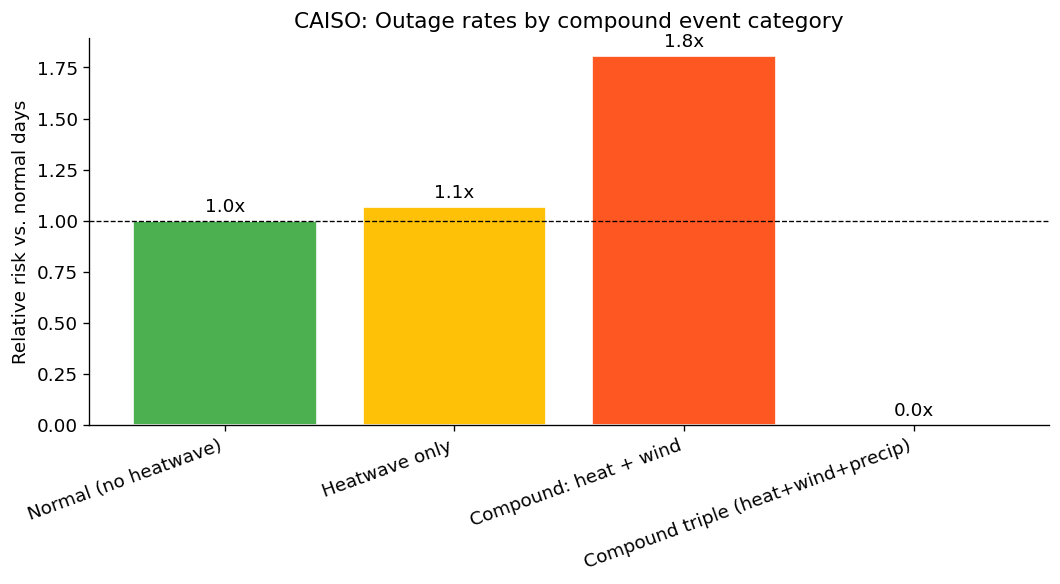

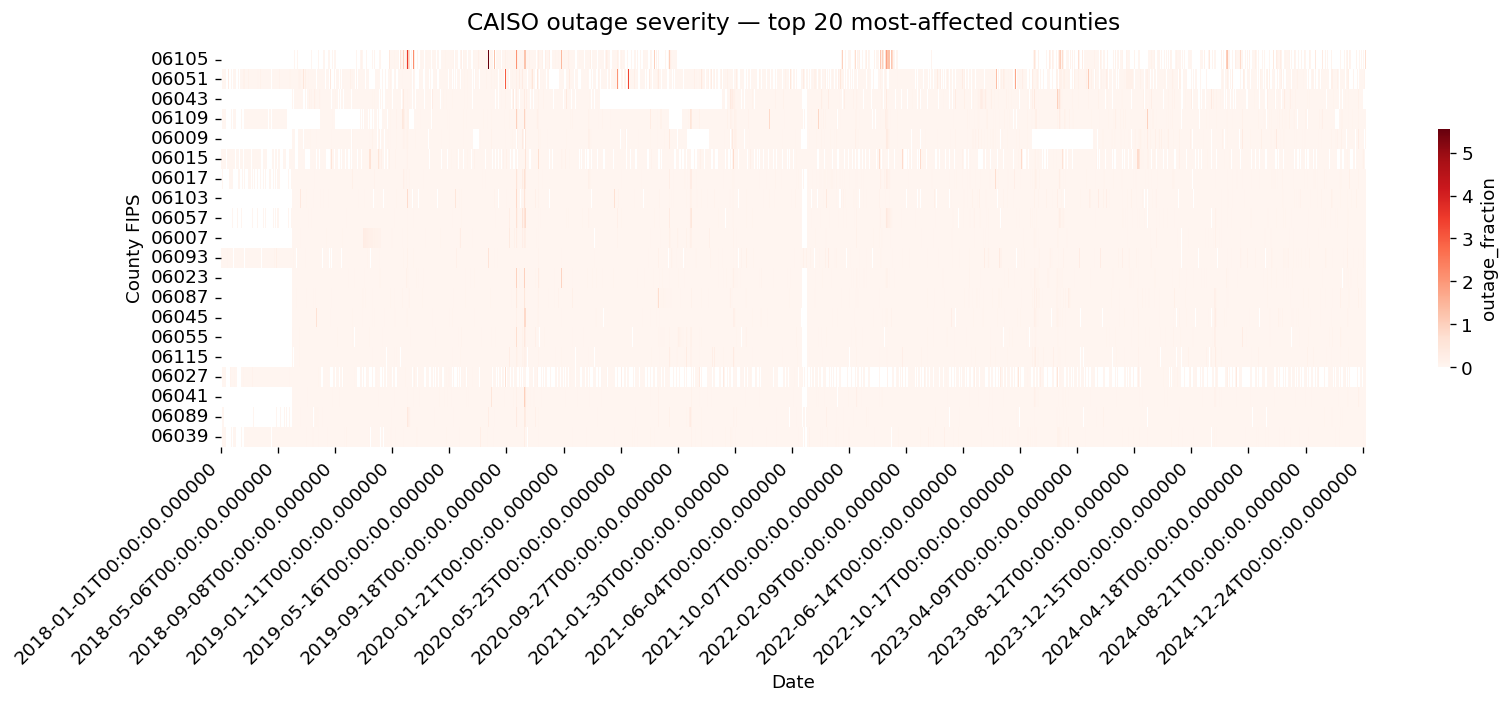


=== CAISO Panel OLS — county FE + month FE, log1p(total_customer_hours) ===


                              PanelOLS Estimation Summary                               
Dep. Variable:     log1p_total_customer_hours   R-squared:                        0.0109
Estimator:                           PanelOLS   R-squared (Between):              0.0331
No. Observations:                      111195   R-squared (Within):               0.0109
Date:                        Sun, May 10 2026   R-squared (Overall):              0.0305
Time:                                14:24:39   Log-likelihood                -2.307e+05
Cov. Estimator:                     Clustered                                           
                                                F-statistic:                      81.305
Entities:                                  50   P-value                           0.0000
Avg Obs:                               2223.9   Distribution:               F(15,111130)
Min Obs:                               689.00                                           
Max Obs:             

                          PanelOLS Estimation Summary                           
Dep. Variable:      outage_event_flag   R-squared:                        0.0007
Estimator:                   PanelOLS   R-squared (Between):              0.0374
No. Observations:              111195   R-squared (Within):               0.0007
Date:                Sun, May 10 2026   R-squared (Overall):              0.0072
Time:                        14:24:39   Log-likelihood                -3.139e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      19.051
Entities:                          50   P-value                           0.0000
Avg Obs:                       2223.9   Distribution:                F(4,111141)
Min Obs:                       689.00                                           
Max Obs:                       2508.0   F-statistic (robust):         -1.319e+17
                            


CAISO bandwidth sensitivity:
   bandwidth          tau          se       p_value     ci_lower     ci_upper  \
0        1.0 -3211.908298  415.222424  1.318334e-14 -4025.994169 -2397.822426   
1        1.5 -2421.351631  389.283862  5.352567e-10 -3184.508460 -1658.194802   
2        2.0 -1964.673883  338.535229  6.780779e-09 -2628.305798 -1301.041967   
3        2.5 -1447.386226  315.812841  4.649525e-06 -2066.458494  -828.313959   
4        3.0 -1140.457931  286.785526  7.037782e-05 -1702.615996  -578.299866   
5        4.0  -853.108274  259.536570  1.015263e-03 -1361.840265  -344.376284   
6        5.0  -648.356295  242.375738  7.480857e-03 -1123.442043  -173.270548   

   n_left  n_right  
0    1944     1780  
1    2874     2424  
2    3982     3003  
3    4994     3292  
4    6168     3731  
5    8085     4318  
6   10460     4664  


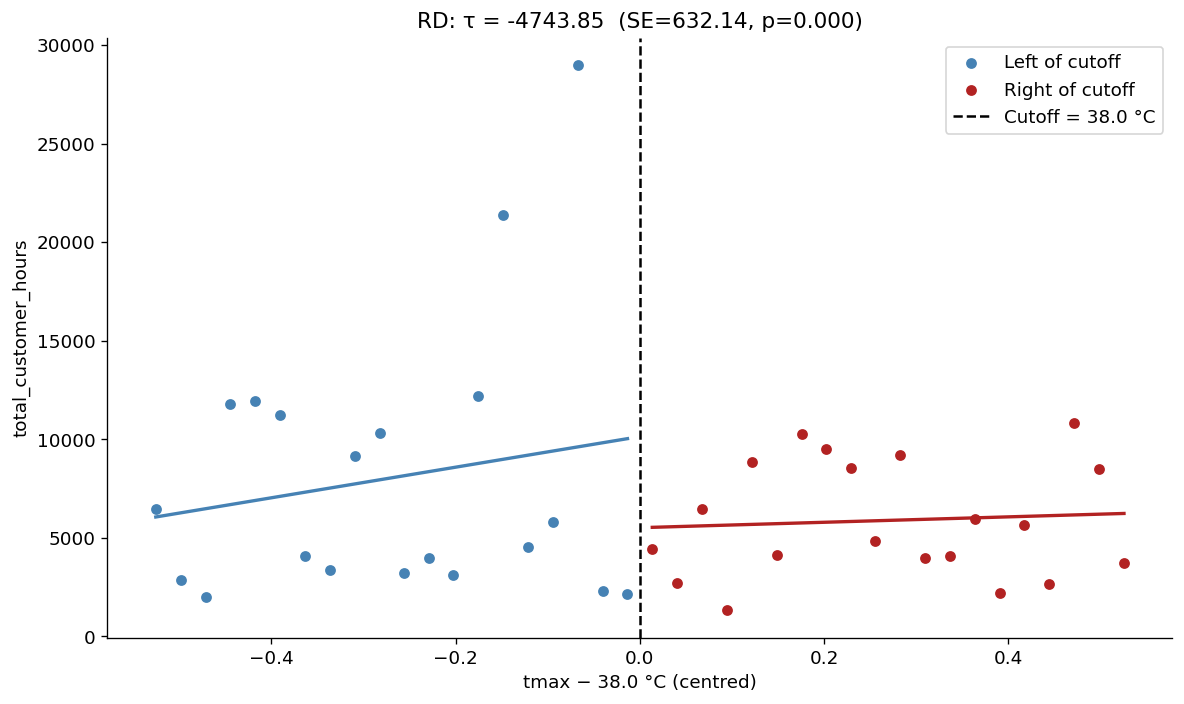

In [9]:
if merged_caiso is not None:
    rates_caiso = outage_rates_by_category(merged_caiso.reset_index())
    print('CAISO outage rates by category:')
    print(rates_caiso.to_string(index=False))

    fig, ax = plt.subplots(figsize=(9, 5))
    outage_rate_bar(rates_caiso, ax=ax, title='CAISO: Outage rates by compound event category')
    plt.tight_layout()
    plt.savefig('../data/processed/caiso_outage_rates.png', dpi=150)
    plt.show()

    fig, ax = plt.subplots(figsize=(14, 6))
    outage_heatmap(
        merged_caiso.reset_index(),
        value_col='outage_fraction',
        top_n_counties=20,
        title='CAISO outage severity — top 20 most-affected counties',
        ax=ax,
    )
    plt.tight_layout()
    plt.savefig('../data/processed/caiso_outage_heatmap.png', dpi=150)
    plt.show()

    print('\n=== CAISO Panel OLS — county FE + month FE, log1p(total_customer_hours) ===')
    result_ols_caiso = run_panel_ols(
        merged_caiso,
        outcome='total_customer_hours',
        use_categories=True,
        log_outcome=True,
        entity_effects=True,
        time_effects=False,
        add_month_fe=True,
    )
    print(result_ols_caiso.summary)
    print('\nCAISO category coefficients:')
    coefs = summarise_results(result_ols_caiso)
    print(coefs[coefs.index.str.startswith('cat_')].round(4))

    print('\n=== CAISO Linear Probability Model — county FE ===')
    result_lpm_caiso = run_logit(
        merged_caiso,
        outcome='outage_event_flag',
        use_categories=True,
        method='lpm',
    )
    print(result_lpm_caiso.summary)
    coefs = summarise_results(result_lpm_caiso)
    print('\nCAISO LPM category coefficients:')
    print(coefs[coefs.index.str.startswith('cat_')].round(4))

    print('\n=== CAISO RD at 38°C — Flex Alert program effect ===')
    print('Interpretation: a negative τ above the cutoff means the Flex Alert reduces outages.')
    print('A robust RD requires consistent sign and magnitude across bandwidths.')
    rd_result_caiso = run_rd(
        merged_caiso.reset_index(),
        cutoff=RD_THRESHOLD_CAISO_C,
        running_var='tmax',
        outcome='total_customer_hours',
    )
    print(rd_result_caiso.summary())

    bw_sens_caiso = rd_bandwidth_sensitivity(merged_caiso.reset_index(), cutoff=RD_THRESHOLD_CAISO_C)
    print('\nCAISO bandwidth sensitivity:')
    print(bw_sens_caiso)

    fig, ax = plt.subplots(figsize=(10, 6))
    rd_plot(merged_caiso.reset_index(), rd_result_caiso, ax=ax)
    plt.tight_layout()
    plt.savefig('../data/processed/caiso_rd_plot.png', dpi=150)
    plt.show()


## 4.8 Save merged panels

In [10]:
if merged_ercot is not None:
    merged_ercot.to_csv(PROCESSED['merged_ercot'])
    print('Saved:', PROCESSED['merged_ercot'])
if merged_caiso is not None:
    merged_caiso.to_csv(PROCESSED['merged_caiso'])
    print('Saved:', PROCESSED['merged_caiso'])


Saved: /burg-archive/home/mck2199/electric-grid-resilience/data/processed/merged_panel_ercot.csv


Saved: /burg-archive/home/mck2199/electric-grid-resilience/data/processed/merged_panel_caiso.csv
